データ: 90件
試合: 2試合


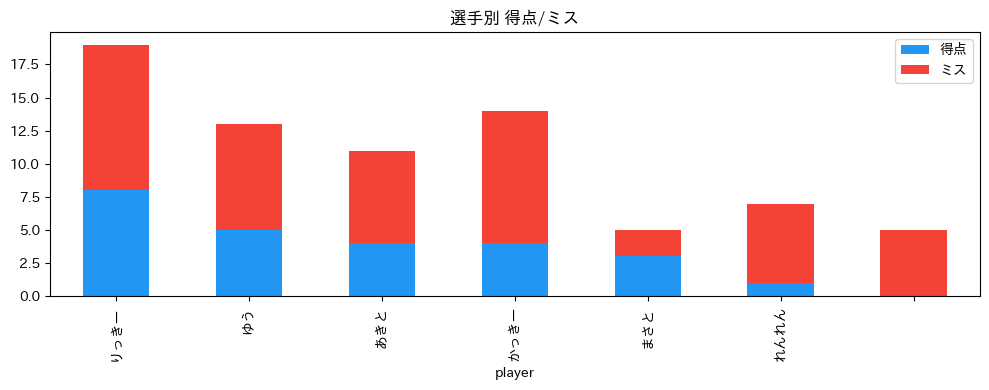

/tmp/ipykernel_16795/3792073408.py:192: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rot = df.groupby('rotation').apply(lambda g: pd.Series({


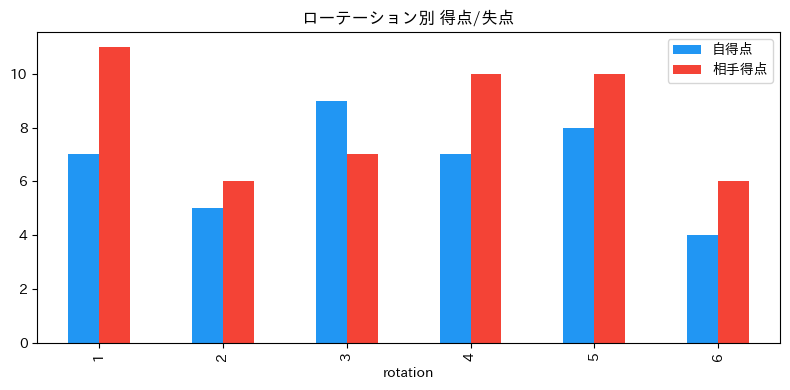

✅ Notion更新完了！


In [5]:
# セル1: セットアップ
!pip install notion-client japanize-matplotlib -q

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from notion_client import Client
import requests
import base64

# === 設定 ===
SHEET_NAME = 'バレースタッツ'
NOTION_TOKEN = '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'  # ← Step1でコピーしたキー
PAGE_ID = '331feaabd15e80b092a8f392c9157be3'           # ← スタッツ分析ページのID

# スプシ接続
creds, _ = default()
gc = gspread.authorize(creds)
ss = gc.open(SHEET_NAME)
ws = ss.worksheet('生データ')
df = pd.DataFrame(ws.get_all_records())

# Notion接続
notion = Client(auth=NOTION_TOKEN)

print(f'データ: {len(df)}件')
print(f'試合: {df["date"].nunique()}試合')

# セル2: 画像アップロード用ヘルパー
def upload_image(filepath):
    """画像をImgurにアップしてURLを返す"""
    with open(filepath, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    res = requests.post(
        'https://api.imgur.com/3/image',
        headers={'Authorization': 'Client-ID 546c25a59c58ad7'},
        data={'image': b64}
    )
    return res.json()['data']['link']

def clear_page(page_id):
    """ページの既存ブロックを全削除"""
    blocks = notion.blocks.children.list(block_id=page_id)
    for block in blocks['results']:
        try:
            notion.blocks.delete(block_id=block['id'])
        except:
            pass

def add_heading(page_id, text, level=2):
    """見出しを追加"""
    notion.blocks.children.append(
        block_id=page_id,
        children=[{
            f'heading_{level}': {
                'rich_text': [{'text': {'content': text}}]
            },
            'type': f'heading_{level}',
        }]
    )

def add_text(page_id, text):
    """テキストを追加"""
    notion.blocks.children.append(
        block_id=page_id,
        children=[{
            'paragraph': {
                'rich_text': [{'text': {'content': text}}]
            },
            'type': 'paragraph',
        }]
    )

def add_image(page_id, url):
    """画像を追加"""
    notion.blocks.children.append(
        block_id=page_id,
        children=[{
            'image': {
                'type': 'external',
                'external': {'url': url}
            },
            'type': 'image',
        }]
    )

def add_table(page_id, headers, rows):
    """テーブルを追加"""
    width = len(headers)
    table_rows = []

    # ヘッダー行
    table_rows.append({
        'type': 'table_row',
        'table_row': {
            'cells': [[{'type':'text','text':{'content':str(h)}}] for h in headers]
        }
    })

    # データ行
    for row in rows:
        table_rows.append({
            'type': 'table_row',
            'table_row': {
                'cells': [[{'type':'text','text':{'content':str(v)}}] for v in row]
            }
        })

    notion.blocks.children.append(
        block_id=page_id,
        children=[{
            'type': 'table',
            'table': {
                'table_width': width,
                'has_column_header': True,
                'has_row_header': False,
                'children': table_rows,
            }
        }]
    )

def add_divider(page_id):
    """区切り線"""
    notion.blocks.children.append(
        block_id=page_id,
        children=[{'type':'divider','divider':{}}]
    )

# セル3: 分析実行 + Notion書き込み

# ページをクリア
clear_page(PAGE_ID)

# === ヘッダー ===
latest_date = df['date'].iloc[-1]
latest_opp = df['opponent'].iloc[-1]
add_heading(PAGE_ID, f'🏐 スタッツ分析', 1)
add_text(PAGE_ID, f'最終更新: {latest_date} vs {latest_opp} | 全{len(df)}ラリー')
add_divider(PAGE_ID)

# === 試合サマリー ===
add_heading(PAGE_ID, '📊 試合サマリー')

for date in df['date'].unique():
    for opp in df[df['date']==date]['opponent'].unique():
        match = df[(df['date']==date) & (df['opponent']==opp)]
        last = match.iloc[-1]
        su = last['score_us']
        st = last['score_them']
        result = '勝ち' if su > st else '負け' if su < st else '引分'
        add_text(PAGE_ID, f'{date} vs {opp}: {su}-{st} ({result})')

add_divider(PAGE_ID)

# === 選手別スタッツ ===
add_heading(PAGE_ID, '👤 選手別スタッツ')

us = df[df['team']=='自チーム']
us_pt = us[us['result']=='得点'].groupby('player').size()
us_ms = us[us['result']=='ミス'].groupby('player').size()

stats = pd.DataFrame({'得点':us_pt,'ミス':us_ms}).fillna(0).astype(int)
stats['合計'] = stats['得点']+stats['ミス']
stats['得点率'] = (stats['得点']/stats['合計']*100).round(1)
stats = stats.sort_values('得点',ascending=False)

headers = ['選手','得点','ミス','合計','得点率']
rows = [[name,r['得点'],r['ミス'],r['合計'],f"{r['得点率']}%"] for name,r in stats.iterrows()]
add_table(PAGE_ID, headers, rows)

# グラフ
fig, ax = plt.subplots(figsize=(10,4))
stats[['得点','ミス']].plot(kind='bar',stacked=True,ax=ax,color=['#2196F3','#f44336'])
plt.title('選手別 得点/ミス')
plt.tight_layout()
plt.savefig('/content/player_stats.png',dpi=150,bbox_inches='tight')
plt.show()

url = upload_image('/content/player_stats.png')
add_image(PAGE_ID, url)

add_divider(PAGE_ID)

# === ローテーション別 ===
add_heading(PAGE_ID, '🔄 ローテーション別')

rot = df.groupby('rotation').apply(lambda g: pd.Series({
    '自得点':(g['point_team']=='自チーム').sum(),
    '相手得点':(g['point_team']!='自チーム').sum(),
})).fillna(0).astype(int)
rot['得点率'] = (rot['自得点']/(rot['自得点']+rot['相手得点'])*100).round(1)

headers = ['ローテ','自得点','相手得点','得点率']
rows = [[r,d['自得点'],d['相手得点'],f"{d['得点率']}%"] for r,d in rot.iterrows()]
add_table(PAGE_ID, headers, rows)

fig, ax = plt.subplots(figsize=(8,4))
rot[['自得点','相手得点']].plot(kind='bar',ax=ax,color=['#2196F3','#f44336'])
plt.title('ローテーション別 得点/失点')
plt.tight_layout()
plt.savefig('/content/rotation.png',dpi=150,bbox_inches='tight')
plt.show()

url = upload_image('/content/rotation.png')
add_image(PAGE_ID, url)

add_divider(PAGE_ID)

# === サーブキャッチ ===
add_heading(PAGE_ID, '🙌 サーブキャッチ分析')

recv = df[df['receive_grade']!='']
if len(recv)>0:
    # 評価分布
    dist = recv['receive_grade'].value_counts().sort_index()
    total = len(recv)
    text = ' | '.join([f'{g}: {c}回({c/total*100:.0f}%)' for g,c in dist.items()])
    add_text(PAGE_ID, text)

    # 評価別得点率
    headers = ['評価','回数','自チーム得点率']
    rows = []
    for g in ['A','B','C','D']:
        gd = recv[recv['receive_grade']==g]
        if len(gd)>0:
            pt = (gd['point_team']=='自チーム').mean()*100
            rows.append([g, len(gd), f'{pt:.1f}%'])
    add_table(PAGE_ID, headers, rows)

    # 選手別キャッチ
    add_text(PAGE_ID, '')
    add_heading(PAGE_ID, '選手別キャッチ評価', 3)
    recv_player = pd.crosstab(recv['receiver'],recv['receive_grade'])
    headers = ['選手'] + list(recv_player.columns)
    rows = [[name]+[recv_player.loc[name].get(c,0) for c in recv_player.columns] for name in recv_player.index]
    add_table(PAGE_ID, headers, rows)

add_divider(PAGE_ID)

# === サイドアウト率 ===
add_heading(PAGE_ID, '📈 サイドアウト率・ブレイク率')

opp_sv = df[df['serve_team']!='自チーム']
so = opp_sv[opp_sv['point_team']=='自チーム']
so_rate = len(so)/len(opp_sv)*100 if len(opp_sv)>0 else 0

us_sv = df[df['serve_team']=='自チーム']
brk = us_sv[us_sv['point_team']=='自チーム']
brk_rate = len(brk)/len(us_sv)*100 if len(us_sv)>0 else 0

add_text(PAGE_ID, f'サイドアウト率: {so_rate:.1f}% ({len(so)}/{len(opp_sv)})')
add_text(PAGE_ID, f'ブレイク率: {brk_rate:.1f}% ({len(brk)}/{len(us_sv)})')

print('✅ Notion更新完了！')

